In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
import re

def extract_maxerr(log_file_path):
    """
    Extract the maxerr value from a log file.
    
    Args:
        log_file_path: Path to the log file
        
    Returns:
        float: The maxerr value, or None if not found
    """
    pattern = r'maxerr\s*=\s*([\d.eE+-]+)'
    
    with open(log_file_path, 'r') as f:
        # Read from the end of the file for efficiency
        lines = f.readlines()
        
        # Search backwards through the last ~20 lines
        for line in reversed(lines[-20:]):
            match = re.search(pattern, line)
            if match:
                return float(match.group(1))
    
    return None

In [3]:
def extract_velocity(velocity_file_path):
    """
    Extract the velocity data from a .npz file.
    
    Args:
        velocity_file_path: Path to the .npz file
    Returns:
        np.ndarray: The velocity data, or None if not found
        maxerr: The maxerr value extracted from the corresponding log file
    """
    if not os.path.exists(velocity_file_path):
        print(f"Velocity file {velocity_file_path} does not exist.")
        return None, None
    
    velocity_data = np.load(velocity_file_path)['drift3d']
    
    # Construct the corresponding log file path
    log_file_path = '/'.join(velocity_file_path.split('/')[:-2]) + '/pochoir.log'
    
    maxerr = extract_maxerr(log_file_path)
    
    # get efield
    path_to_efield = '/'.join(velocity_file_path.split('/')[:-2]) + '/velocity/efield.npz'
    efield = np.load(path_to_efield)['efield']/1e-6
    return velocity_data, maxerr, efield

In [4]:
list_steps = [1300, 2600, 3900, 5000, 10000, 50_000, 100_000]
list_steps = [100_000, 500_000, '1M']
# list_steps = [500_000, '1M']

In [2]:
speed_unit = 0.001

efield shape: (3, 44, 44, 1500), velocity shape: (3, 44, 44, 1500), maxerr: 1.69e-03
efield shape: (3, 44, 44, 1500), velocity shape: (3, 44, 44, 1500), maxerr: 5.59e-05
efield shape: (3, 44, 44, 1500), velocity shape: (3, 44, 44, 1500), maxerr: 8.33e-07


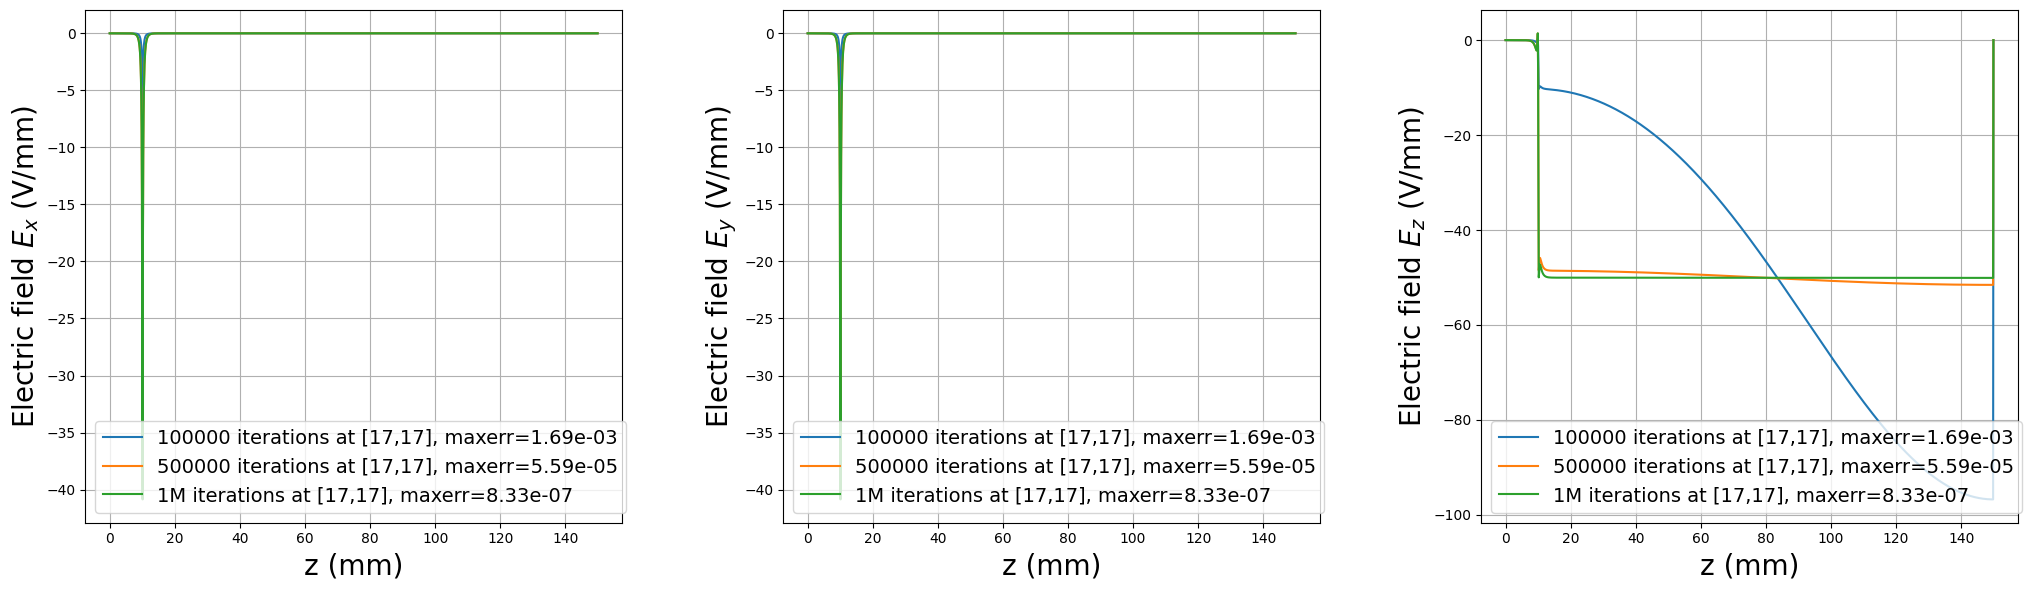

In [25]:
list_velocities = []
for steps in list_steps:
    path_to_velocity_file = f'../store_{steps}steps/velocity/drift3d.npz'
    velocity_data, maxerr, efield = extract_velocity(path_to_velocity_file)
    list_velocities.append((velocity_data, maxerr, efield))
for i, (velocity_data, maxerr, efield) in enumerate(list_velocities):
    print(f'efield shape: {efield.shape}, velocity shape: {velocity_data.shape}, maxerr: {maxerr:.2e}')
# plt.figure(figsize=(10, 6))
axes  = ['x', 'y', 'z']
fig, ax = plt.subplots(1,3, figsize=(21, 6))
for j in range(3):
    for i, (velocity_data, maxerr, efield) in enumerate(list_velocities):
        # ax[j].plot(np.arange(velocity_data.shape[3])*0.1, velocity_data[j, 17,17,:]/speed_unit, label=f'{list_steps[i]} iterations at [17,17], maxerr={maxerr:.2e}')
        ax[j].plot(np.arange(efield.shape[3])*0.1, efield[j, 17,17,:], label=f'{list_steps[i]} iterations at [17,17], maxerr={maxerr:.2e}')
    ax[j].set_xlabel('z (mm)', fontsize=20)
    # ax[j].set_ylabel(f'Drift velocity $v_{axes[j]}$ (mm/us)', fontsize=20)
    ax[j].set_ylabel(f'Electric field $E_{axes[j]}$ (V/mm)', fontsize=20)
    ax[j].grid(True)
    # ax[j].set_ylabel('Electric field $E_z$ (V/mm)', fontsize=20)
    # ax[j].set_xticks(fontsize=20)
    # ax[j].set_xticks(fontsize=20)
    # ax[j].set_yticks(fontsize=20)
    ax[j].legend(fontsize=14)
# plt.ylim([0, -100])
plt.tight_layout()
plt.show()

In [2]:
v0 = np.load('../store/velocity/efield.npz')['efield']
# v1 = np.load('../store_1Msteps_allFloat64_torchCompile/velocity/drift3d.npz')['drift3d']
# v2 = np.load('../store_1Msteps_allFloat32/velocity/efield.npz')['efield']
# v3 = np.load('../store_1Msteps_allFloat32_nonZeroArr/velocity/efield.npz')['efield']
# v4 = np.load('../store_10000steps/velocity/drift3d.npz')['drift3d']

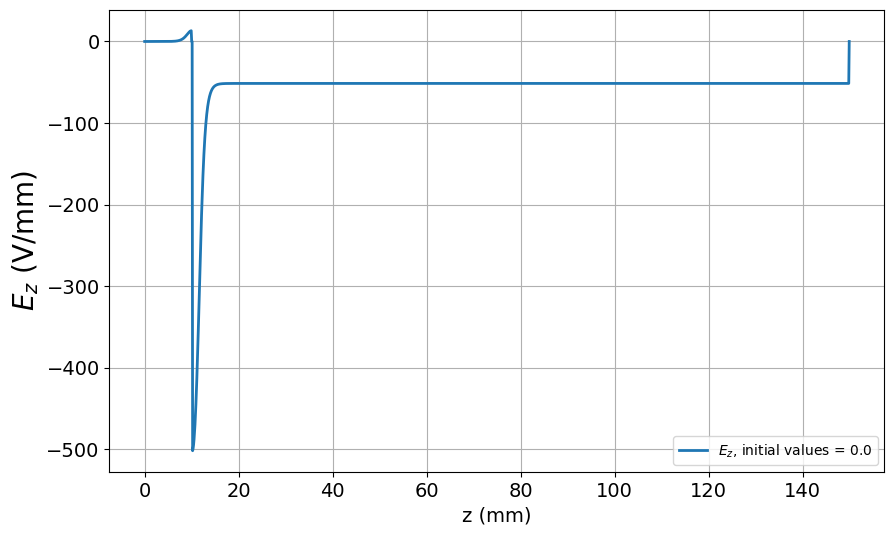

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(np.arange(v0.shape[3])*0.1, v0[2, 0,0,:]/1e-6, linewidth=2,label=r'$E_z$, initial values = 0.0')
# plt.plot(np.arange(v1.shape[3])*0.1, v1[2, 0,0,:]/1e-6, label=r'$E_z$ 1M*10 iterations at [0,0], initial values : linear along z')
# plt.plot(np.arange(v1.shape[3])*0.1, v1[2, 0,0,:]/1e-6, label=r'$E_z$ 1M*10 iterations at [0,0], initial values : 0.0, compiled')
# plt.plot(np.arange(v2.shape[3])*0.1, v2[2, 0,0,:]/1e-6, 'c--', label=r'$E_z$ 1M*10 iterations at [0,0], [float32, float32, float32]')
# plt.plot(np.arange(v3.shape[3])*0.1, v3[2, 0,0,:]/1e-6, 'm--', label=r'$E_z$ 1M*10 iterations at [0,0], [float32, float32, float32, non zero iarr]')
# plt.plot(np.arange(v2.shape[3])*0.1, v2[2, 0,0,:], label=r'$v_z$ 3900 iterations at [0,0]')
# plt.plot(np.arange(v3.shape[3])*0.1, v3[2, 0,0,:], label=r'$v_z$ 5000 iterations at [0,0]')
# plt.plot(np.arange(v4.shape[3])*0.1, v4[2, 0,0,:], label=r'$v_z$ 10000 iterations at [0,0]')
plt.xlabel('z (mm)', fontsize=14)
plt.ylabel(r'$E_z$ (V/mm)', fontsize=20)
# plt.title("Electric field [bi_core, tmp_core, iarr_pad] = float64 dtypes", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.xlim([7,12])
# plt.ylim([-100, 0])
plt.grid(True)
plt.legend()

In [9]:
path_to_inital_values = '../store/potential/drift3d.npz'
iarr = np.load(path_to_inital_values)['drift3d']
print(f'iarr shape: {iarr.shape}, iarr dtype: {iarr.dtype}')

iarr shape: (44, 44, 1500), iarr dtype: float64


/tmp/ipykernel_3920066/999588116.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=14)


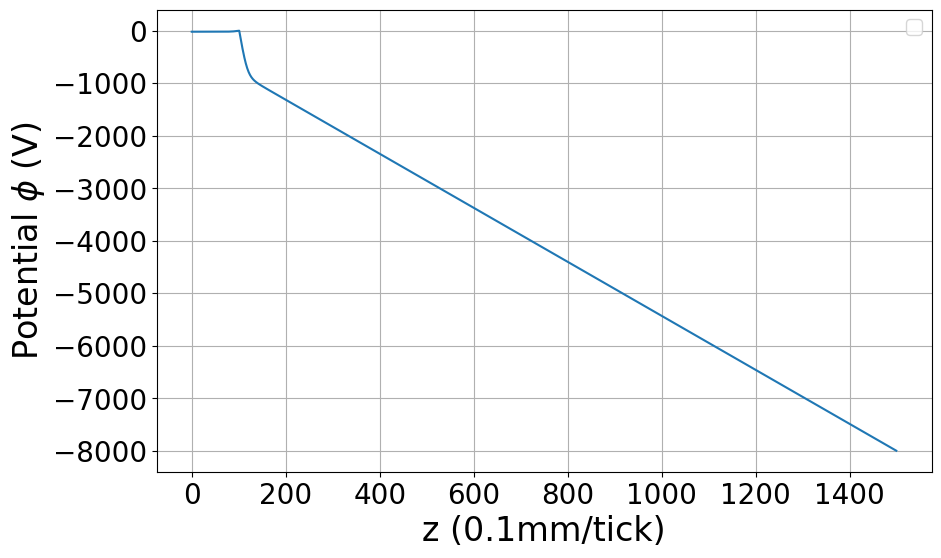

In [14]:
plt.figure(figsize=(10, 6))
# for i in range(5):
#     plt.plot(np.arange(iarr.shape[2]), iarr[i, i,:], label=f'iarr[{i},{i},:]')
## phi0
# plt.plot(np.arange(iarr.shape[2]), iarr[0, 0,:], label=r'$-\nabla^2 \phi_0$[0,0,:]')
# plt.xlabel('z (0.1mm/tick)', fontsize=14)
# plt.ylabel(r'Source term $-\nabla^2 \phi_0$', fontsize=14)
## delta
# plt.plot(np.arange(iarr.shape[2]), iarr[0, 0,:], label=r'$\delta$[0,0,:]')
# plt.xlabel('z (0.1mm/tick)', fontsize=14)
# plt.ylabel(r'Solution $\delta$', fontsize=14)
## phi0 + delta
plt.plot(np.arange(iarr.shape[2]), iarr[0, 0,:])#, label=r'($\phi_0 + \delta$)[0,0,:]')
plt.xlabel('z (0.1mm/tick)', fontsize=24)
# plt.ylabel(r'Solution $\phi_0 + \delta$', fontsize=14)
plt.ylabel(r'Potential $\phi$ (V)', fontsize=24)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True)
# plt.xlim(0, 200)
# plt.ylim(-200, 1)
# plt.xlim(148, 149.25)
# plt.ylim(-7002, -6750)
# plt.xlim(99, 102)
# plt.ylim(-175, 2)
plt.legend(fontsize=14)
plt.show()


In [23]:
potential_file_path = '../store/potential/drift3d_float32.npz'
potential = np.load(potential_file_path)['drift3d_float32']
exp_phi0 = np.load('../store/potential/phi0_withBC.npz')['phi0_withBC']
padded_phi0 = np.load('../store/potential/padded_phi0.npz')['padded_phi0']
stencil = np.load('../store/potential/stencil.npz')['stencil']
print(f'potential shape: {potential.shape}, potential dtype: {potential.dtype}')
# print(f'max stencil value: {np.max(stencil)}, min stencil value: {np.min(stencil)}')

potential shape: (44, 44, 150), potential dtype: float32


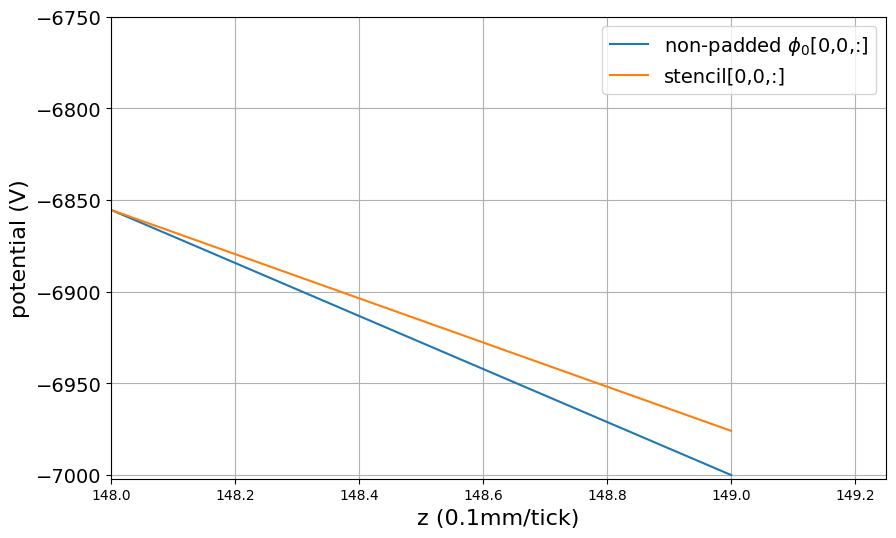

In [36]:
plt.figure(figsize=(10, 6))
plt.plot(np.arange(potential.shape[2]), potential[0,0,:], label=r'non-padded $\phi_0$[0,0,:]')
# plt.plot(np.arange(padded_phi0.shape[2]), padded_phi0[1,1,:], label=r'padded $\phi_0$[1,1,:]')
# plt.plot(np.arange(padded_phi0.shape[2]), padded_phi0[0,0,:], label=r'padded $\phi_0$[0,0,:]')
plt.plot(np.arange(stencil.shape[2]), stencil[0,0,:], label='stencil[0,0,:]')
# plt.plot(np.arange(potential.shape[2]), potential[0,1,:], label='potential[0,1,:]')
# plt.plot(np.arange(potential.shape[2]), potential[1,0,:], label='potential[1,0,:]')
# plt.plot(np.arange(potential.shape[2]), potential[2,1,:], label='potential[2,1,:]')
# plt.plot(np.arange(potential.shape[2]), potential[1,2,:], label='potential[1,2,:]')
# plt.plot(np.arange(exp_phi0.shape[2]), exp_phi0[1,1,:], label=r'$\phi_0$ with BC[1,1,:]')
# plt.plot(np.arange(iarr.shape[2]), iarr[0, 0,:], label=r'iarr[0,0,:]')
plt.xlabel('z (0.1mm/tick)', fontsize=16)
plt.ylabel('potential (V)', fontsize=16)
# plt.xticks(np.arange(potential.shape[2]), fontsize=14)
plt.yticks( fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)
# plt.xlim(99, 102)
# plt.ylim(-175, 2)
plt.xlim(148, 149.25)
plt.ylim(-7002, -6750)
plt.show()

In [130]:
pot_5X5 = potential[:5, :5, :]
print(f'pot_5X5: {pot_5X5}')
print(pot_5X5.shape)

pot_5X5: [[[  -44.683746   -44.683758   -44.683777 ... -6710.801    -6855.4014
   -7000.      ]
  [  -44.683746   -44.683758   -44.683777 ... -6710.802    -6855.402
   -7000.      ]
  [  -44.683746   -44.683758   -44.683777 ... -6710.8037   -6855.4023
   -7000.      ]
  [  -44.683746   -44.683758   -44.683777 ... -6710.806    -6855.4033
   -7000.      ]
  [  -44.683746   -44.683758   -44.683777 ... -6710.8086   -6855.4053
   -7000.      ]]

 [[  -44.683746   -44.683758   -44.683777 ... -6710.802    -6855.402
   -7000.      ]
  [  -44.683746   -44.683758   -44.683777 ... -6710.8027   -6855.4023
   -7000.      ]
  [  -44.683746   -44.683758   -44.683777 ... -6710.804    -6855.4023
   -7000.      ]
  [  -44.683746   -44.683758   -44.683777 ... -6710.8066   -6855.404
   -7000.      ]
  [  -44.683746   -44.683758   -44.683777 ... -6710.8096   -6855.406
   -7000.      ]]

 [[  -44.683746   -44.683758   -44.683777 ... -6710.8037   -6855.4023
   -7000.      ]
  [  -44.683746   -44.683758   -44

In [63]:
pot_5X5[1,1,151]

IndexError: index 151 is out of bounds for axis 2 with size 150

In [67]:
k_interest = pot_5X5[1,1,148]
avg_nbrs = (pot_5X5[0,1,148] + pot_5X5[2,1,148] + pot_5X5[1,0,148] + pot_5X5[1,2,148] + pot_5X5[1,1,147] + pot_5X5[1,1,149]) / 6
print(f'k_interest: {k_interest}, avg_nbrs: {avg_nbrs}')
print(f'Difference: {k_interest - avg_nbrs}, Relative difference: {(k_interest - avg_nbrs)/avg_nbrs:.2e}')

k_interest: -6855.40234375, avg_nbrs: -6855.40234375
Difference: 0.0, Relative difference: -0.00e+00


In [20]:
pot_5X5[1,1,149]

np.float64(-7000.0)

['drift3d.npz', 'drift3d_epoch0.npz', 'drift3d_epoch1.npz', 'drift3d_epoch2.npz', 'drift3d_epoch3.npz', 'drift3d_epoch4.npz', 'drift3d_epoch5.npz', 'drift3d_epoch6.npz', 'drift3d_epoch7.npz', 'drift3d_epoch8.npz', 'drift3d_epoch9.npz']


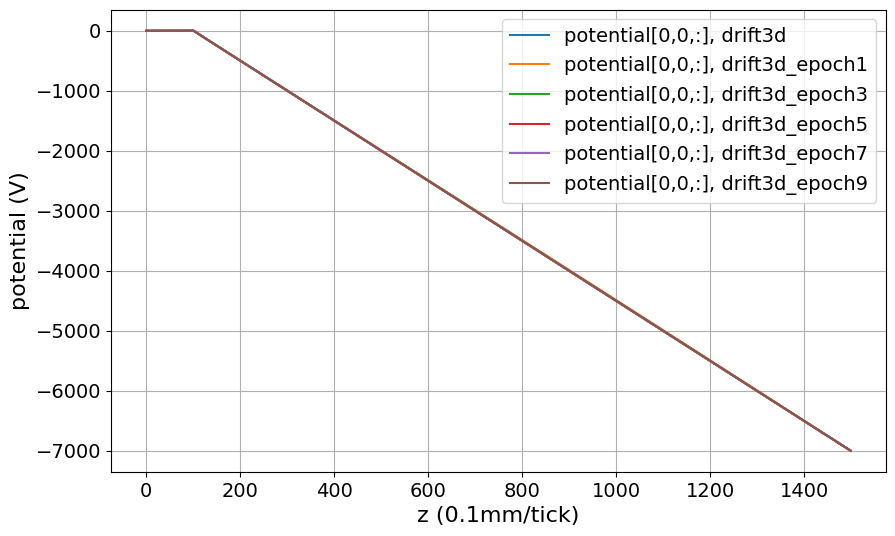

In [34]:
list_potentials = [f for f in os.listdir('../store/potential') if f.endswith('.npz')]
list_potentials.sort()
print(list_potentials)
plt.figure(figsize=(10, 6))
for i, f in enumerate(list_potentials):
    if i%2!=0:
        continue
    potential_file_path = os.path.join('../store/potential', f)
    potential = np.load(potential_file_path)[f.split('/')[-1].split('.')[0]]
    plt.plot(np.arange(potential.shape[2]), potential[0,0,:], label=f'potential[0,0,:], {f.split("/")[-1].split(".")[0]}')
plt.xlabel('z (0.1mm/tick)', fontsize=16)
plt.ylabel('potential (V)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim()
plt.grid(True)
plt.legend(fontsize=14)
plt.show()

In [28]:

path_to_err = '../store/increment/drift3d.npz'
err_data = np.load(path_to_err)['drift3d']


2026-03-08 23:59:37,146 - root - INFO - using FDM engine torch
2026-03-08 23:59:37,454 - root - INFO - bi_core shape = torch.Size([44, 44, 1500]), mutable_core shape = torch.Size([44, 44, 1500]), tmp_core shape = torch.Size([44, 44, 1500]), 
	iarr_pad_shape = torch.Size([46, 46, 1502])
2026-03-08 23:59:37,454 - root - INFO - bi_core device = cuda:1, mutable_core device = cuda:1, tmp_core device = cuda:1, 
	iarr_pad_device = cuda:1
2026-03-08 23:59:37,454 - root - INFO - bi_core dtype = torch.float32, mutable_core dtype = torch.float32, tmp_core dtype = torch.float32, 
	iarr_pad_dtype = torch.float32
2026-03-08 23:59:37,454 - root - INFO - PYTHON OVERHEAD : FOR Loops
2026-03-08 23:59:37,454 - root - INFO - ====== epoch: 0/10 x 1000000 ===============
2026-03-09 00:00:54,749 - root - INFO - epoch 0 time: 77.30 seconds
2026-03-09 00:00:54,749 - root - INFO - ====== epoch: 1/10 x 1000000 ===============
2026-03-09 00:02:09,954 - root - INFO - epoch 1 time: 75.20 seconds
2026-03-09 00:02:09

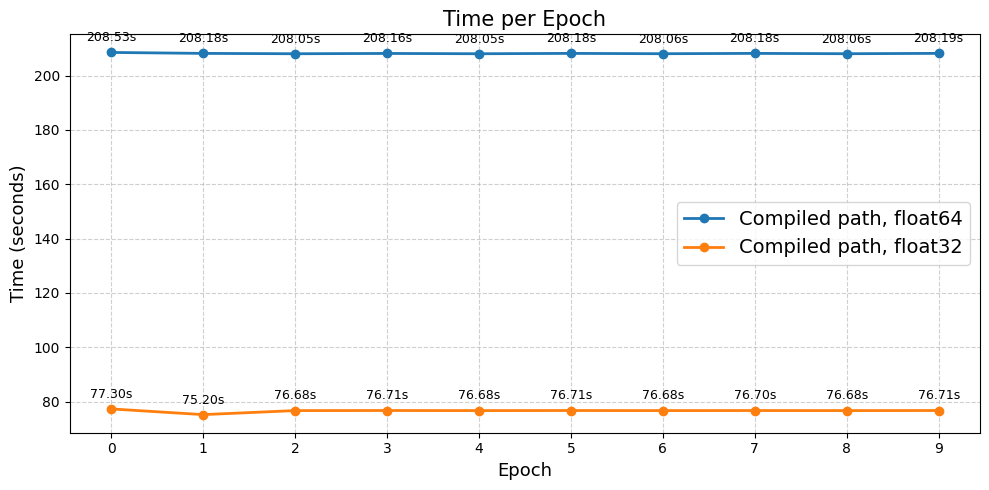

In [15]:


import re
import sys
import matplotlib.pyplot as plt

def parse_epoch_times(log_text):
    pattern = r"epoch (\d+) time: ([\d.]+) seconds"
    matches = re.findall(pattern, log_text)
    epochs = [int(m[0]) for m in matches]
    times = [float(m[1]) for m in matches]
    return epochs, times

def plot_epoch_times(fig, ax, epochs, times, label):
    # fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(epochs, times, marker='o', linewidth=2, markersize=6, label=label)
    ax.set_xlabel("Epoch", fontsize=13)
    ax.set_ylabel("Time (seconds)", fontsize=13)
    ax.set_title("Time per Epoch", fontsize=15)
    ax.set_xticks(epochs)
    ax.grid(True, linestyle='--', alpha=0.6)

    for e, t in zip(epochs, times):
        ax.annotate(f"{t:.2f}s", (e, t), textcoords="offset points",
                    xytext=(0, 8), ha='center', fontsize=9)

    # plt.tight_layout()
    # plt.savefig("epoch_times.png", dpi=150)
    # print("Plot saved to epoch_times.png")
    # plt.show()

with open('../store_1Msteps_allFloat32_torchCompile/pochoir.log', "r") as f:
    log_text = f.read()
print(log_text)
epochs, times = parse_epoch_times(log_text)

with open('../store_1Msteps_allFloat64_torchCompile/pochoir.log', "r") as f:
    log_text_ = f.read()
print(log_text_)
epochs_, times_ = parse_epoch_times(log_text_)
# if not epochs:
#     print("No epoch time entries found in the log.")
#     sys.exit(1)

print(f"Found {len(epochs)} epochs:")
for e, t in zip(epochs, times):
    print(f"  Epoch {e}: {t:.2f} seconds")

# plot_epoch_times(epochs, times)
fig, ax = plt.subplots(figsize=(10, 5))
plot_epoch_times(fig, ax, epochs_, times_, label='Compiled path, float64')
plot_epoch_times(fig, ax, epochs, times, label='Compiled path, float32')
# ax.set_ylim([205, 250])
ax.legend(fontsize=14)
plt.tight_layout()
plt.show()

## plottting the initial values for the weighting field

In [1]:
import numpy as np
import matplotlib.pyplot as plt
def draw_weight3d(path_to_weight, z_index, showerr=False):
    weight3d = np.load(path_to_weight)['weight3d']
    print(f'weight3d shape: {weight3d.shape}, weight3d dtype: {weight3d.dtype}')
    if showerr:
        weighterr_path = None
        splitted_path = path_to_weight.split('/')
        splitted_path[2] = 'increment'
        weighterr_path = '/'.join(splitted_path)
        # try:
        #     weighterr_path = path_to_weight.replace('initial', 'increment')
        # except:
        #     weighterr_path = path_to_weight.replace('potential', 'increment')
        weighterr = np.load(weighterr_path)['weight3d']
        maxerr = np.max(np.abs(weighterr))
        print(f'maxerr: {maxerr:.2e}, path to err: {weighterr_path}')
    
    # make a 2d plot of weight3d[:,:, z_index]
    plt.figure(figsize=(10, 6))
    plt.imshow(weight3d[:,:, z_index], cmap='viridis')
    plt.colorbar(label=f'weight3d[:,:, {z_index}]')
    plt.title(f'2D plot of weight3d[:,:, {z_index}]', fontsize=16)
    plt.xlabel('x index', fontsize=14)
    plt.ylabel('y index', fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.grid(False)
    plt.show()

weight3d shape: (220, 220, 1500), weight3d dtype: float64


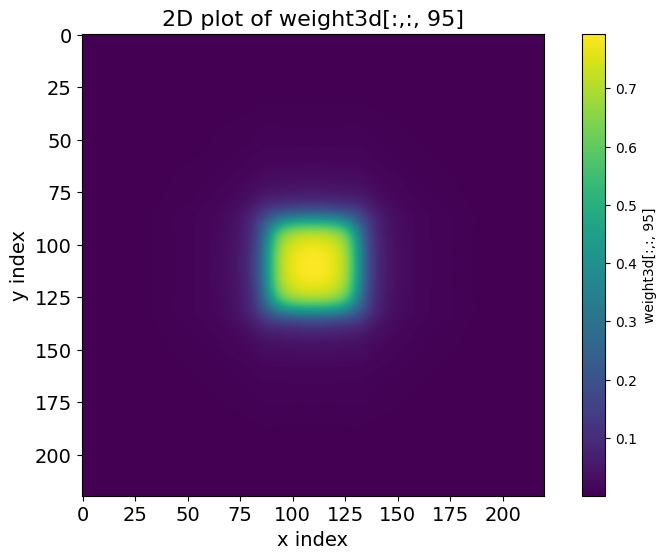

In [2]:
path_to_weight = '../store_1Msteps_allFloat64_torchCompile_0driftinit_idwWeightInit/potential/weight3d.npz'
draw_weight3d(path_to_weight, z_index=95)

weight3d shape: (220, 220, 1500), weight3d dtype: float64


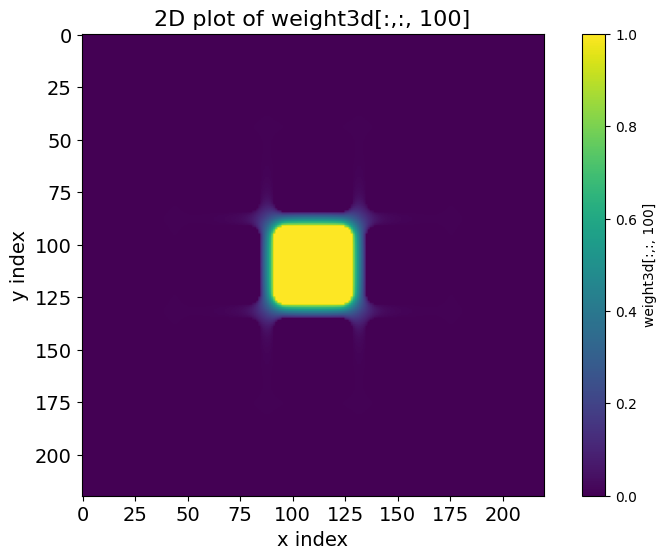

In [3]:
path_to_weight = '../store_1Msteps_allFloat64_torchCompile_0driftinit_idwWeightInit/potential/weight3d.npz'
draw_weight3d(path_to_weight, z_index=100)

weight3d shape: (220, 220, 1500), weight3d dtype: float64


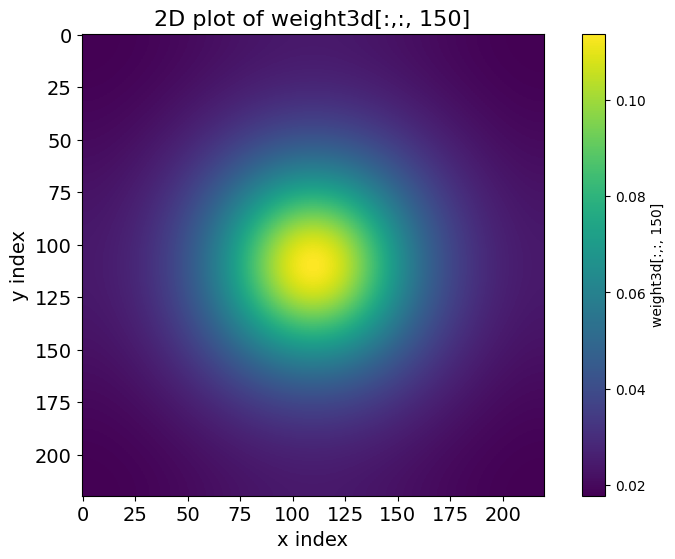

In [4]:
path_to_weight = '../store_1Msteps_allFloat64_torchCompile_0driftinit_idwWeightInit/potential/weight3d.npz'
draw_weight3d(path_to_weight, z_index=150)

In [7]:
## plot weight3d in 3d 
path_to_weight = '../store/potential/weight3d.npz'
weight3d = np.load(path_to_weight)['weight3d']

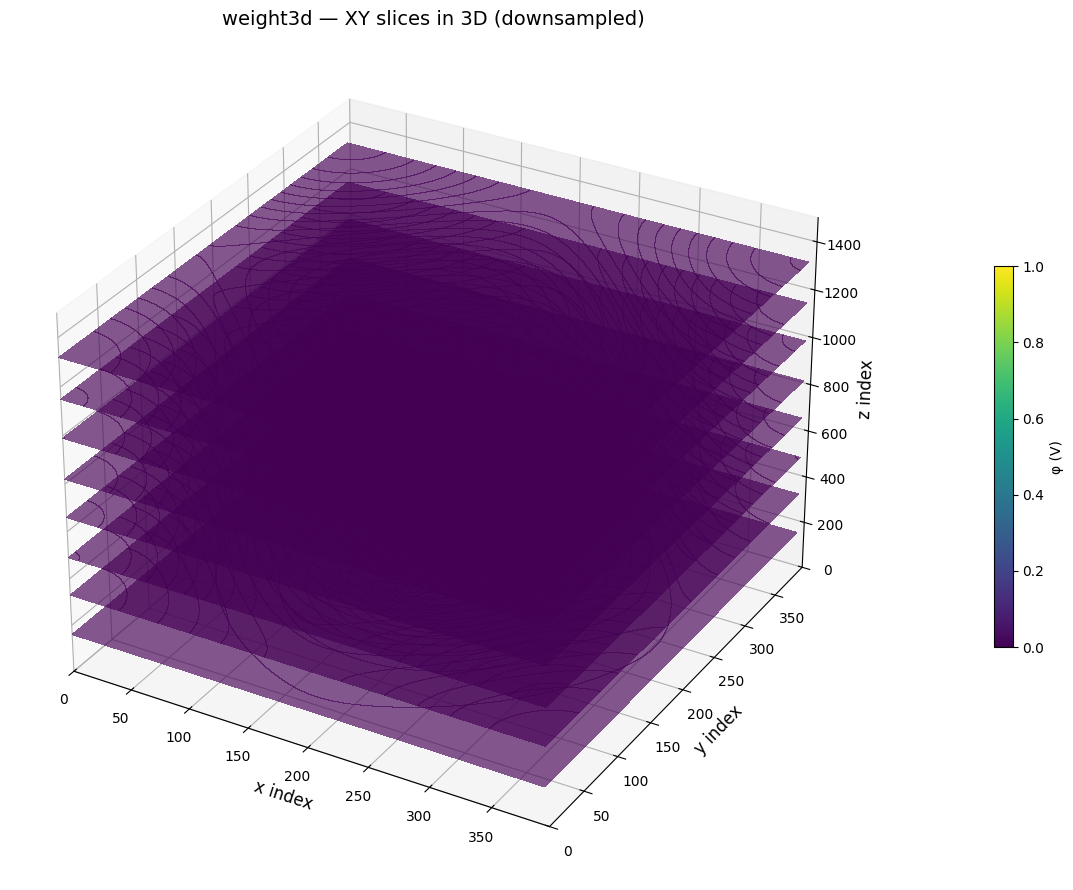

In [8]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import numpy.ma as ma

# Downsample to keep rendering fast
step_xy = 4   # every 4th pixel in x/y  → 55×55 per slice
step_z  = 10  # every 10th slice in z

w = weight3d[::step_xy, ::step_xy, ::step_z]
nx, ny, nz = w.shape

x = np.arange(nx) * step_xy
y = np.arange(ny) * step_xy
z = np.arange(nz) * step_z

X, Y = np.meshgrid(x, y, indexing='ij')

vmin, vmax = float(w[w != 0].min()), float(w.max())
cmap = 'viridis'
n_slices = min(10, nz)
z_indices = np.linspace(0, nz - 1, n_slices, dtype=int)

fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')

for iz in z_indices:
    slice_data = ma.masked_where(np.abs(w[:, :, iz]) < 1e-10, w[:, :, iz])
    ax.contourf(X, Y, slice_data,
                zdir='z', offset=int(z[iz]),
                cmap=cmap, vmin=vmin, vmax=vmax,
                levels=20, alpha=0.65)

ax.set_xlim(0, weight3d.shape[0])
ax.set_ylim(0, weight3d.shape[1])
ax.set_zlim(0, weight3d.shape[2])
ax.set_xlabel('x index', fontsize=12)
ax.set_ylabel('y index', fontsize=12)
ax.set_zlabel('z index', fontsize=12)
ax.set_title('weight3d — XY slices in 3D (downsampled)', fontsize=14)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
plt.colorbar(sm, ax=ax, shrink=0.45, pad=0.1, label='φ (V)')

plt.tight_layout()
plt.show()

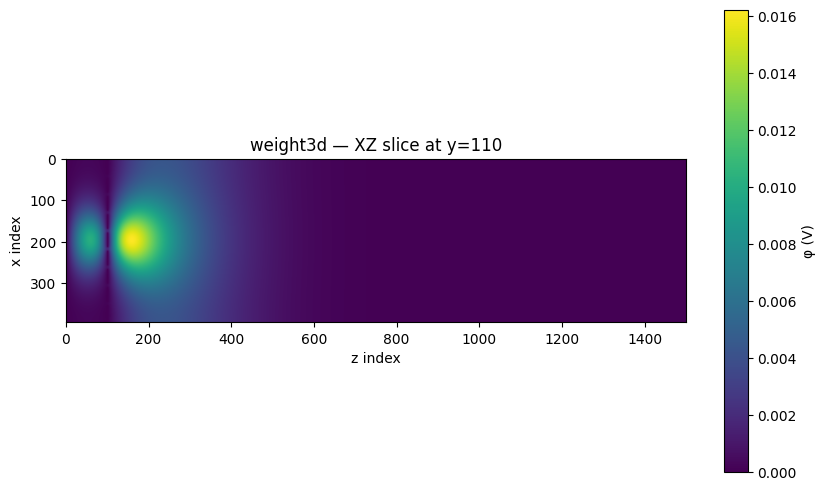

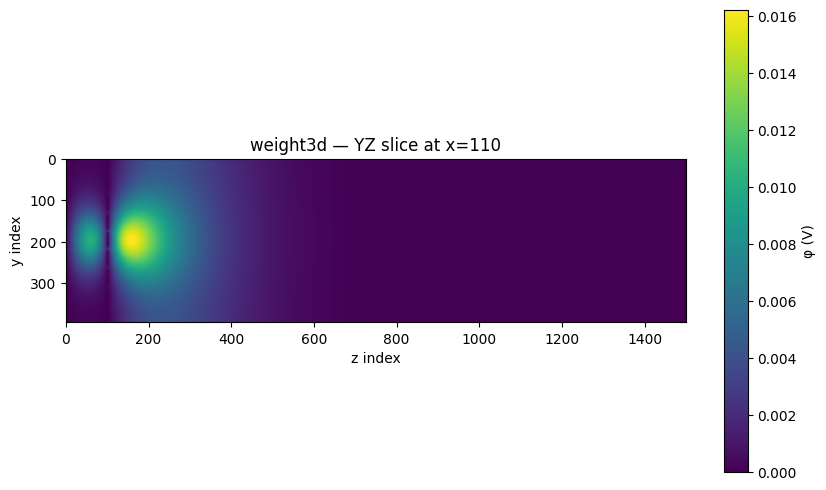

In [9]:
plt.figure(figsize=(10, 6))
plt.imshow(weight3d[:, 110, :], cmap='viridis')
plt.colorbar(label='φ (V)')
plt.xlabel('z index')
plt.ylabel('x index')
plt.title('weight3d — XZ slice at y=110')
plt.show()

plt.figure(figsize=(10, 6))
plt.imshow(weight3d[110, :, :], cmap='viridis')
plt.colorbar(label='φ (V)')
plt.xlabel('z index')
plt.ylabel('y index')
plt.title('weight3d — YZ slice at x=110')
plt.show()

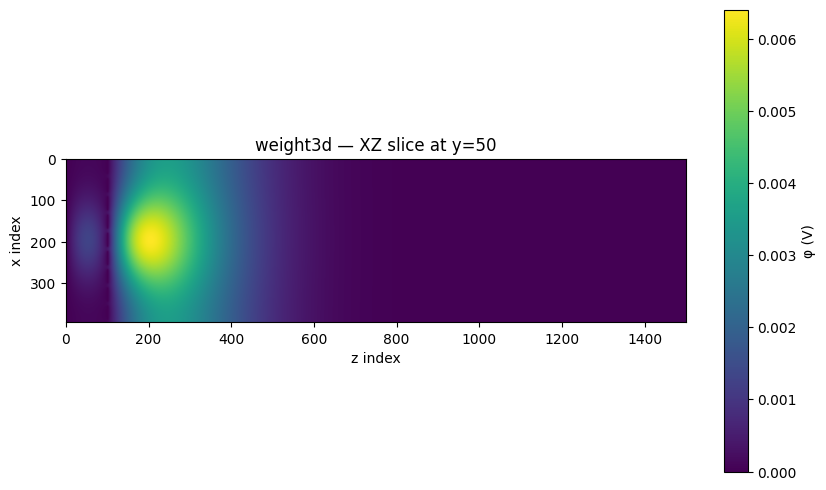

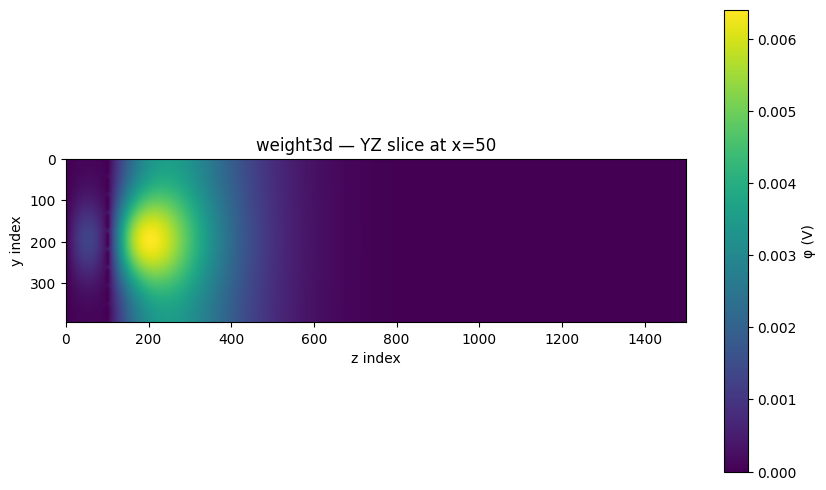

In [10]:
plt.figure(figsize=(10, 6))
plt.imshow(weight3d[:, 50, :], cmap='viridis')
plt.colorbar(label='φ (V)')
plt.xlabel('z index')
plt.ylabel('x index')
plt.title('weight3d — XZ slice at y=50')
plt.show()

plt.figure(figsize=(10, 6))
plt.imshow(weight3d[50, :, :], cmap='viridis')
plt.colorbar(label='φ (V)')
plt.xlabel('z index')
plt.ylabel('y index')
plt.title('weight3d — YZ slice at x=50')
plt.show()

weight3d shape: (220, 220, 1500), weight3d dtype: float64
maxerr: 1.19e-07, path to err: ../store_ok_driftsteps13000000_wsteps500000_pix5x5/increment/weight3d.npz


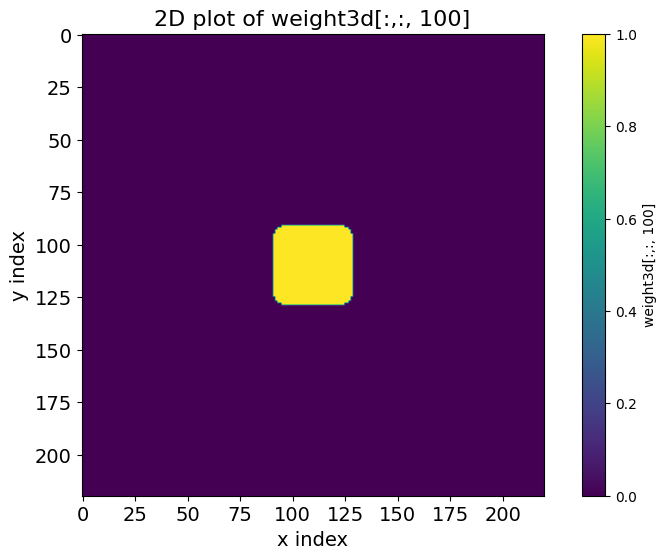

In [2]:
path_to_weight = '../store_ok_driftsteps13000000_wsteps500000_pix5x5/initial/weight3d.npz'
draw_weight3d(path_to_weight, z_index=100, showerr=True)

weight3d shape: (220, 220, 1500), weight3d dtype: float64
maxerr: 1.79e-07, path to err: ../store_ok_driftsteps1300000_wsteps1000000_pix5x5/increment/weight3d.npz


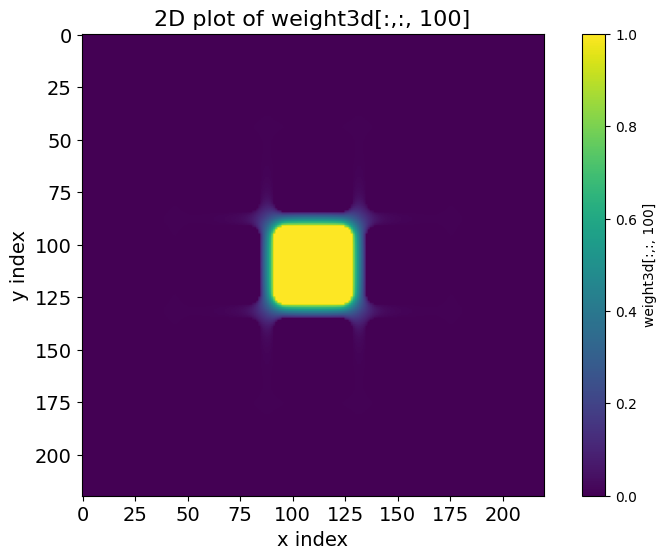

In [25]:
path_to_weight = '../store_ok_driftsteps1300000_wsteps1000000_pix5x5/potential/weight3d.npz'
draw_weight3d(path_to_weight, z_index=100, showerr=True)